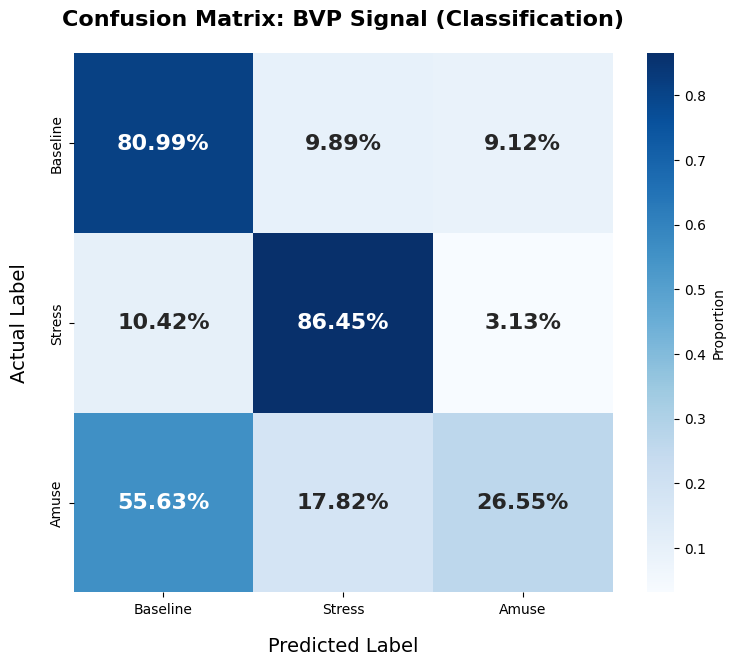

In [ ]:

import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, confusion_matrix, classification_report

#Load the saved LOSO classification results (change to results you want to analyse)
with open('Results/results_BVP_LOSO_CLASS.pkl', 'rb') as f:
    results = pickle.load(f)

all_preds = []
all_true = []

#Combine predictions and true labels from all subjects
for subject, data in results.items():
    all_preds.extend(data['y_pred'])
    all_true.extend(data['y_true'])

#Compute the normalized confusion matrix
cm = confusion_matrix(all_true, all_preds, normalize='true')

plt.style.use('default')

fig, ax = plt.subplots(figsize = (9, 7))

#Visualize the confusion matrix
sns.heatmap(cm, annot=True, fmt='.2%', cmap='Blues', 
            annot_kws= {'size': 16, 'weight': 'bold'},
            xticklabels=['Baseline', 'Stress', 'Amuse'], 
            yticklabels=['Baseline', 'Stress', 'Amuse'],
            cbar_kws ={'label': 'Proportion'},
            square = True)

#Add labels and title
ax.set_xlabel('Predicted Label', fontsize = 14, labelpad = 15)
ax.set_ylabel('Actual Label', fontsize = 14, labelpad = 15)
ax.set_title('Confusion Matrix: BVP Signal (Classification)', fontsize = 16, pad = 20, fontweight = 'bold' )

#Optimize figure layout and save the plot
plt.tight_layout()
plt.savefig('class_confusion_BVP_matrix2.png', dpi = 300, bbox_inches = 'tight')
plt.show()

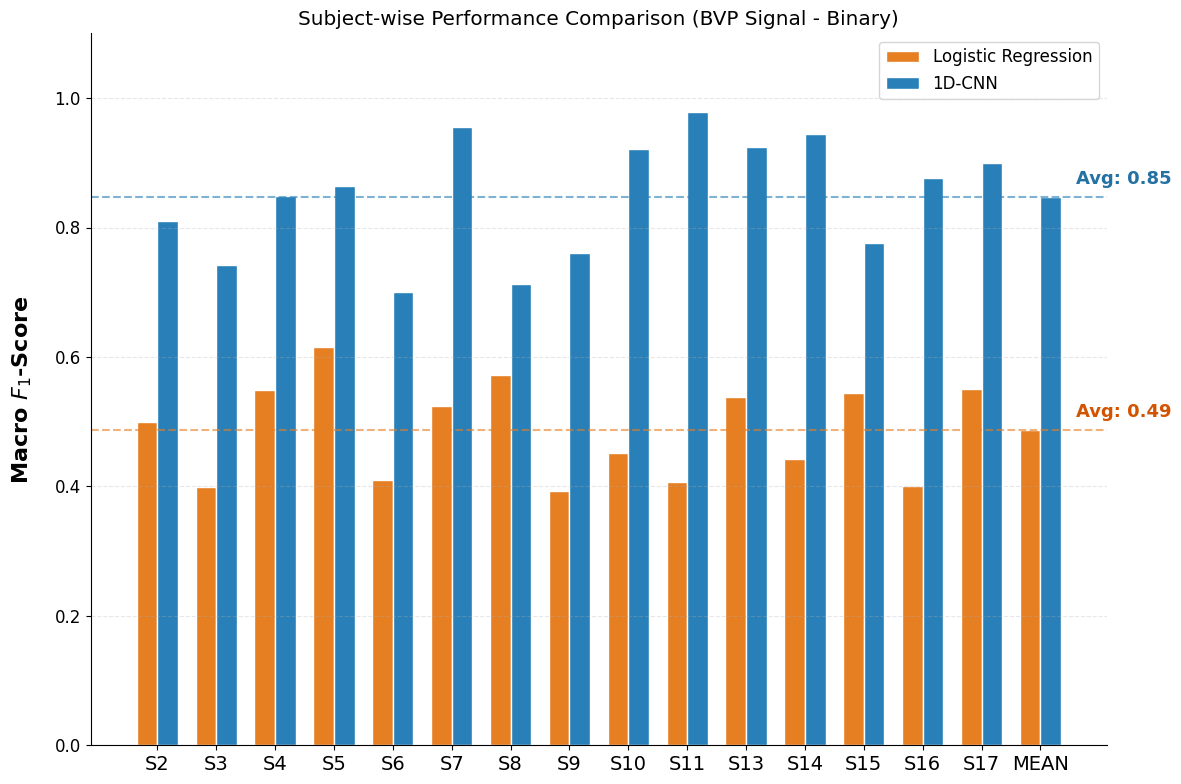

In [ ]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

#Set default font size for all figures
plt.rcParams.update({'font.size': 12})

def get_subject_f1s(filepath):
    """
    Compute the Macro F1-score for each subject from saved LOSO results.
    """
    #Load the saved results
    with open(filepath, 'rb') as f:
        results = pickle.load(f)
    
    subject_f1s = {}

    #Sort subjects numerically (S2, S3, ..., S17)
    for subject in sorted(results.keys(), key=lambda x: int(x[1:])):
        y_true = results[subject]['y_true']
        y_pred = results[subject]['y_pred']

        #Compute Macro F1-score for the current subject
        score = f1_score(y_true, y_pred, average='macro')
        subject_f1s[subject] = score

    return subject_f1s

#Load the saved model results

baseline_f1s = get_subject_f1s('baseline_results/baseline_BVP.pkl')
cnn_f1s = get_subject_f1s('Results/results_BVP_LOSO_BINARY2.pkl')

#Extract subject names and F1-scores
subjects = list(baseline_f1s.keys())

base_values = [baseline_f1s[s] for s in subjects]
cnn_values = [cnn_f1s[s] for s in subjects]

#Add an additional column containing the mean score
plot_subjects = subjects + ["MEAN"]

plot_base = base_values + [np.mean(base_values)]
plot_cnn = cnn_values + [np.mean(cnn_values)]

#Create the comparison plot

x = np.arange(len(plot_subjects))
width = 0.35

plt.style.use('seaborn-v0_8-muted')

fig, ax = plt.subplots(figsize=(12, 8))

#Plot the subject-wise F1-scores
rects1 = ax.bar(x - width/2, plot_base, width, label='Logistic Regression', color="#E67E22", edgecolor = "white")
rects2 = ax.bar(x + width/2, plot_cnn, width, label='1D-CNN', color='#2980B9', edgecolor = "white")

#Add labels and title
ax.set_ylabel('Macro $F_1$-Score', fontsize = 16, fontweight = 'bold', labelpad = 15)

ax.set_title('Subject-wise Performance Comparison (BVP Signal - Binary)')

ax.set_xticks(x)
ax.set_xticklabels(plot_subjects, fontsize = 14)

ax.set_ylim(0, 1.1)

#Improve readability of the plot
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(axis='y', linestyle = '--', alpha = 0.3)

#Compute the average performance of both models
mean_base = np.mean(base_values)
mean_cnn = np.mean(cnn_values)

#Add horizontal lines indicating average performance
line_base = ax.axhline(mean_base, color='#E67E22', linestyle='--', alpha=0.6, linewidth=1.5)
line_cnn = ax.axhline(mean_cnn, color='#2980B9', linestyle='--', alpha=0.6, linewidth=1.5)

#Add text labels for the average scores
ax.text(len(plot_subjects)-0.4, mean_base + 0.02, f'Avg: {mean_base:.2f}', color='#D35400', fontweight='bold', fontsize = 13)
ax.text(len(plot_subjects)-0.4, mean_cnn + 0.02, f'Avg: {mean_cnn:.2f}', color='#2471A3', fontweight='bold', fontsize = 13)

#Add legend
ax.legend(frameon=True, fontsize = 12, loc = 'upper right')

#Optimize layout and save figure
plt.tight_layout()
plt.savefig('subject_comparison_bvp2.png', dpi = 300, bbox_inches = 'tight')
plt.show()